In [8]:
%matplotlib inline

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
# from tqdm import tqdm_notebook as tqdm
import math
import skfuzzy as fuzz
import sys


#**************************************************************************************************************************************
# we have 2 fuzzy sets of angles:
# set1(θ) = “how much I believe the angle is θ” from source 1
# set2(θ) = same from source 2

# Think: two sensors, or two pieces of information about direction, each uncertain.
# “If I combine these two vague directions into one final direction (by averaging them as vectors), what is the fuzzy belief over all possible output angles?”

# So, we are building a new fuzzy set:
# average_angle(θ) = “how plausible is it that the combined direction is θ?”
# And optionally:
# confidence_level(θ) = “how strongly do the input directions agree when giving angle θ?”
# This is like a fuzzy convolution on a circle: combining two fuzzy beliefs into a third one.
#**************************************************************************************************************************************


# scikit-fuzzy (imported as fuzz) is a library for fuzzy logic and fuzzy systems — built on top of NumPy and SciPy.
# It provides:
# Membership functions (fuzz.trimf, fuzz.gaussmf, etc.)
# Fuzzy c-means clustering (fuzz.cluster.cmeans)
# Fuzzy inference systems (rules, defuzzification, etc.)

# our domain, [0, 360]
SubSample = 1 # do we want to downsample the resolution of X (takes awhile otherwise)
degree_domain = np.asarray( range(0,360,SubSample) )

# Create fuzzy set 1
set1 = np.zeros( np.asarray(range(0,360,SubSample)).size )  # remark: range(start, stop, step)  The np.asarray() converts the range object into a Numpy array.
# domain = np.arange(0, 360, 1)
if(0): # We can adjust this flow control to test different membership function.
    a = 35
    b = 45
    c = 55
else:
    a = 88
    b = 90
    c = 92
set1 = fuzz.trimf(degree_domain, [a, b, c]) # fuzz.trimf(pts, [a, b, c]) The first value is the universe of the values(domain) of the membership function. [a,b,c] are the 3points of the triangle

# For example this set1 is like:
# set1[0]   = 0
# set1[1]   = 0
# .........
# set1[88]  = 0
# set1[89]  = 0.5
# set1[90]   = 1
# set1[91]   = 0.5
# set1[92]   = 0
# set1[93]   = 0
# ........

# fuzzy set 2
set2 = np.zeros( np.asarray(range(0,360,SubSample)).size )
# domain = np.arange(0, 360, 1)
if(1):
    a = 305
    b = 315
    c = 325
else:
    a = 268
    b = 270
    c = 272
set2 = fuzz.trimf(degree_domain, [a, b, c])

# This function convert the coordinate to angle from 0 to 360.
def calculate_angle_degree(x, y):
    angle = math.atan2(y, x) # The angle in radius.
    if angle < 0:
        angle += 2.0 * math.pi # If the angle is in [-pi,0], make it be in [pi,2*pi]
    angle = (180 / math.pi) * angle # Convert radians to degrees.
    return angle

# This function is to takes 2 angles in degree, combines them as vectors, and returns:
# 1.The direction halfway between them(in degree)
# 2. The magnitude(strength) of the combined vector.
# This is the classic vector-based fuzzy aggregation. 
def direction_combiner( degree1, degree2 ):
    # convert to vector
    vector1 = np.asarray([ math.cos(degree1 * (math.pi/180)) , math.sin(degree1 * (math.pi/180)) ])
    vector2 = np.asarray([ math.cos(degree2 * (math.pi/180)) , math.sin(degree2 * (math.pi/180)) ])
    # The (cos(x),sin(x)) is supposed to be unit vector. The following step is to prevent rounding error.
    vector1 = vector1/np.linalg.norm(vector1) # np.linalg.norm() just calculates the length of a vector.
    vector2 = vector2/np.linalg.norm(vector2)   
    average_vector = (vector1 + vector2)/2 # c is between a and b. And c's magnitude depends on how aligned a and b are.
    average_degree = calculate_angle_degree(average_vector[0],average_vector[1]) # Use the previous function to convert the angle to [0,359] degree.
    if(average_degree > 359): 
        average_degree = 360 - average_degree
    return average_degree, np.linalg.norm(average_vector)

#************** Start 

# Initialize output fuzzy set:
average_angle = np.zeros( degree_domain.size )

# The confidence_level is NOT the membership, it a separate measure.
# It’s like saying:
# “Even in the worst case, when θ is produced from inputs, how well did those inputs agree?”
# This is a conservative way to define the confidence level. It's a lower bound of agreements.
confidence_level = np.ones( degree_domain.size ) 

# Get sizes of output, set1, and set2.
output_size = degree_domain.size # size of output angles
set1_size = set1.size # number of points in fuzzy set A
set2_size = set2.size # number of points in fuzzy set B

# This is the core of this algorithm:
# The outer loop interates over each angle degree in the domain:
# As for each degree, we examine all possible combinations of elements in set1 and set2, we can find all combinations that can produce the degree in outer loop
# Aor each combination, we compare: 1. how much input 1 supports θ₁  2. how much input 2 supports θ₂ 3. how well those directions actually agree (strength)
# # The membership is restricted by 3 factors:
# set1[j] is small (θ₁ is unlikely), or
# set2[k] is small (θ₂ is unlikely), or
# strength is small (θ₁ and θ₂ contradict each other, then this pair cannot strongly support θ)
# Finally, we use the sup-min composition rule to find the membership of each angle

for i in tqdm(range(output_size),mininterval=0.5,file=sys.stdout):
    # The inner loops interate over all possible combinations (It's like the cross product of 2 sets):
    for j in range(set1_size): # go over all x
        for k in range(set2_size): # go over all y
            indx1 = math.floor(j/SubSample)
            indx2 = math.floor(k/SubSample)
            angle, strength = direction_combiner( degree_domain[indx1], degree_domain[indx2] ) # r is the resulting direction(in angle degree), l is the length
            r_round = round(angle) # round r to nearest degree
            # The final membership of a particular degree is found by "the max of mins"
            if( r_round == degree_domain[i] ): # We care about the memberships only if these 2 angles selected can form the degree_domain[i]
                m = min( set1[j], set2[k], strength ) # A[j] is the membership of angle θ₁ in fuzzy set A. B[k]is the membership of angle θ2 in fuzzy set B. l is the strength of combining these 2 directions.          
                if( m > average_angle[i] ):
                    average_angle[i] = m          # we are taking the sup
                confidence_level[i] = min( confidence_level[i], strength ) # We find the minimum strength in all combinations

# plot it!
# The Matplotlib returns two objects: 1. the whole window 2. The individual plot area inside the window. 1,1 means 1 row and 1 column => 1 plot
# layout='constrained' means labels titles etc are not going to overlap.
fig, ax = plt.subplots(1, 1, layout='constrained', figsize=(14,6))
plt.stem(set1[::SubSample],'k',markerfmt='ko') # ,use_line_collection=True
plt.stem(set2[::SubSample],'r',markerfmt='ro') # ,use_line_collection=True
plt.stem(average_angle,'g',markerfmt='gx') # ,use_line_collection=True
#plt.stem(Conf,markerfmt='go',use_line_collection=True)
b=range(0,output_size)
plt.fill_between( b, average_angle, color="skyblue", alpha=0.3)
#plt.fill_between( b, Conf, color="yellow", alpha=0.05)
xi = list(range(len(degree_domain)))
plt.xticks(xi, degree_domain)  
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
plt.grid()
plt.show()

 12%|█▏        | 42/360 [01:49<13:46,  2.60s/it]


KeyboardInterrupt: 

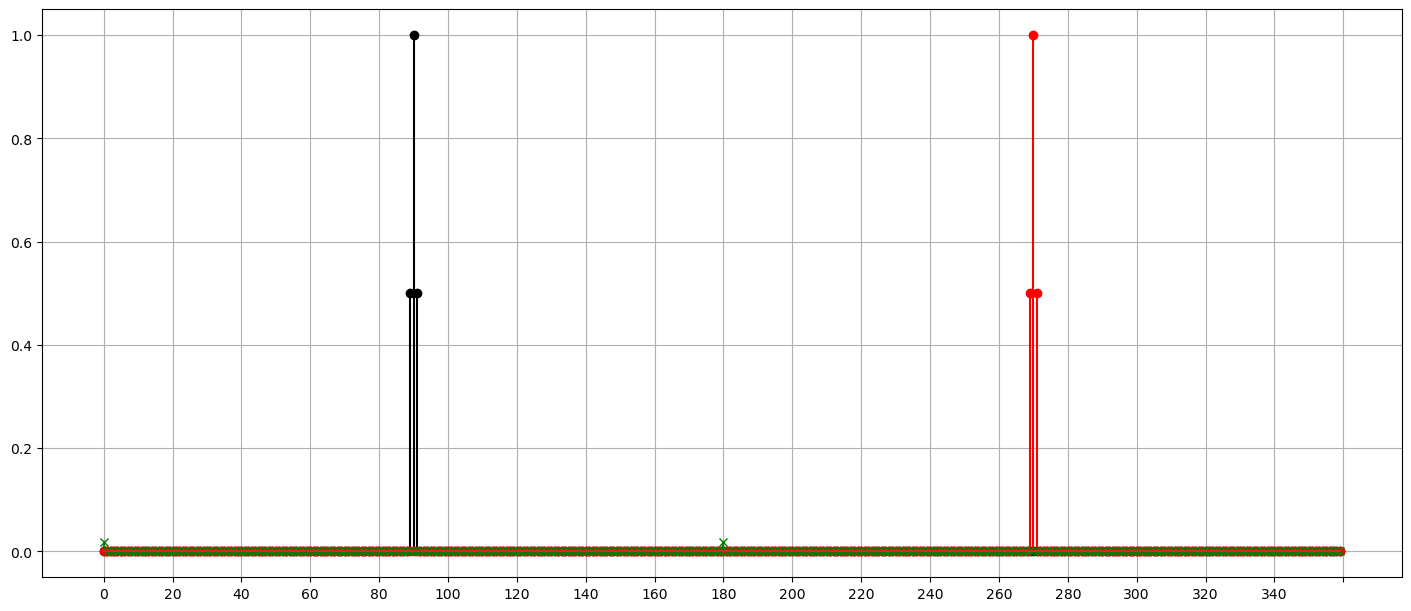

In [ ]:
# plot it!
fig, ax = plt.subplots(1, 1, layout='constrained', figsize=(14,6))
plt.stem(set1[::SubSample],'k',markerfmt='ko') # ,use_line_collection=True
plt.stem(set2[::SubSample],'r',markerfmt='ro') # ,use_line_collection=True
plt.stem(average_angle,'g',markerfmt='gx') # ,use_line_collection=True
#plt.stem(Conf,markerfmt='go',use_line_collection=True)
b=range(0,output_size)
plt.fill_between( b, average_angle, color="skyblue", alpha=0.3)
#plt.fill_between( b, Conf, color="yellow", alpha=0.05)
xi = list(range(len(degree_domain)))
plt.xticks(xi, degree_domain)  
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
plt.grid()
plt.show()

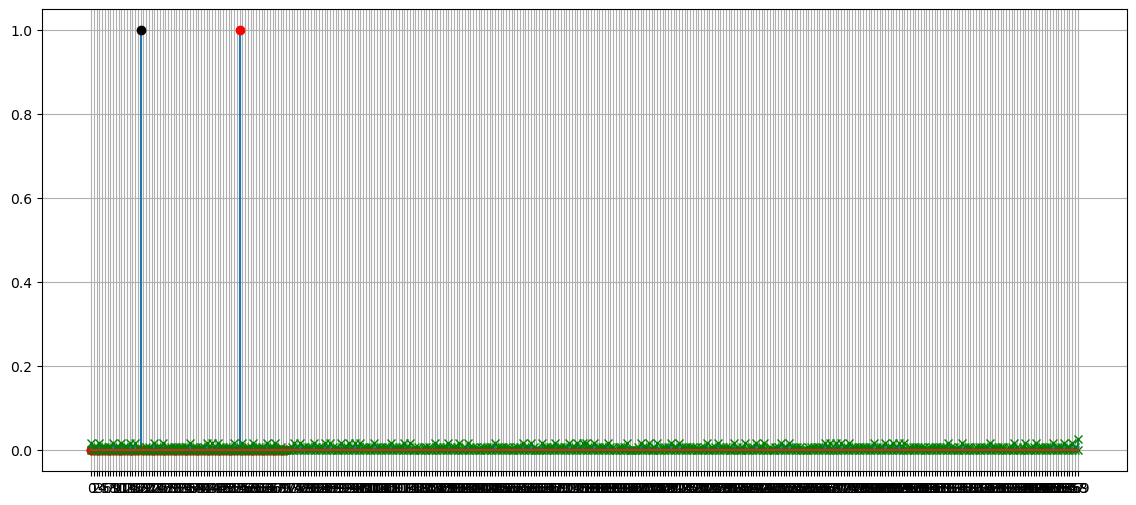

In [7]:
# plot it!
fig = plt.figure(figsize=(14, 6))
plt.stem(set1[::5],markerfmt='ko') # ,use_line_collection=True
plt.stem(set2[::5],markerfmt='ro') # ,use_line_collection=True
plt.stem(average_angle,markerfmt='gx') # ,use_line_collection=True
plt.stem(confidence_level,markerfmt='gx') # ,use_line_collection=True
b=range(0,output_size)
plt.fill_between( b, average_angle, color="skyblue", alpha=0.4)
plt.fill_between( b, confidence_level, color="yellow", alpha=0.4)
xi = list(range(len(degree_domain)))
plt.xticks(xi, degree_domain)  
plt.grid()
plt.show()